In [1]:
import numpy as np
import pandas as pd

from statsmodels.tsa.api import adfuller, kpss, range_unit_root_test

import pandas_datareader.data as web

# настройки визуализации
import matplotlib.pyplot as plt

# Не показывать Warnings
import warnings
warnings.simplefilter(action='ignore', category=Warning)

In [2]:
y = np.log( web.DataReader(name='GDP', data_source='fred', start='1990-1', end='2023-12') )

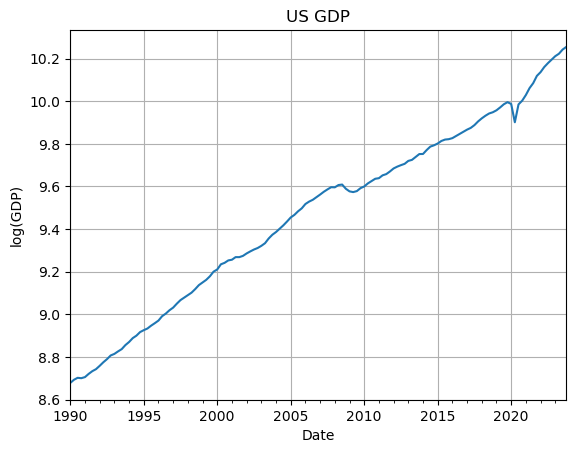

In [3]:
ax = y.plot(title='US GDP')

# надпись по ос oX
ax.set_xlabel('Date')
# надпись по ос oY
ax.set_ylabel('log(GDP)')
# отобразить сетку
ax.grid()
# удалим легенду
ax.legend().remove()

plt.show()

# ADF-тест

In [4]:
adf_stat, pval, usedlag, nobs, critical_values, BIC = adfuller(y, regression='ct', autolag='BIC')
# тестовая статистика, её p-значение и критические значения
adf_stat, pval, critical_values

(np.float64(-1.6310075226710312),
 np.float64(0.780055926576031),
 {'1%': np.float64(-4.027444361631865),
  '5%': np.float64(-3.443525725854798),
  '10%': np.float64(-3.146427052278616)})

In [5]:
adf_stat, pval, usedlag, nobs, critical_values, BIC = adfuller(y.diff().dropna(), regression='c', autolag='BIC')
# тестовая статистика, её p-значение и критические значения
adf_stat, pval, critical_values

(np.float64(-12.236047692712336),
 np.float64(1.0275912662851829e-22),
 {'1%': np.float64(-3.480118600110386),
  '5%': np.float64(-2.8833618426136196),
  '10%': np.float64(-2.578407034974382)})

# KPSS-тест

In [6]:
kpss_stat, p_value, lags, crit = kpss(y, regression='ct')
# тестовая статистика, её p-значение и критические значения
kpss_stat, p_value, crit

(np.float64(0.33641036940731844),
 np.float64(0.01),
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

In [8]:
kpss_stat, p_value, lags, crit = kpss(y.diff().dropna(), regression='c')
# тестовая статистика, её p-значение и критические значения
kpss_stat, p_value, crit

(np.float64(0.14298122660526166),
 np.float64(0.1),
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

# Выбор порядка ARMA

In [9]:
from statsmodels.tsa.stattools import arma_order_select_ic

In [10]:
# Используем информационные критерии AIC, AICC, BIC, HQIC
res = arma_order_select_ic(y.diff().dropna(), max_ar=4, max_ma=4, ic=['aic', 'aicc', 'bic', 'hqic'], trend='c')

In [11]:
# оптимальный порядок по AIC
res.aic_min_order

(np.int64(0), np.int64(0))

In [12]:
# значения критерия AIC по всем моделям
res.aic

,0,1,2,3,4
0,-793.811593,-792.229320,-791.541779,-790.042468,-788.110030
1,-792.339492,-790.120711,-790.300837,-788.035443,-786.103606
2,-791.368934,-789.059099,-788.251235,-786.503957,-784.449241
3,-790.216712,-788.226133,-786.311279,-784.539137,-782.448582
4,-788.232258,-786.245598,-784.319635,-782.495385,-781.219473


In [13]:
# оптимальный порядок по AICc
res.aicc_min_order

(np.int64(0), np.int64(0))

In [14]:
# оптимальный порядок по BIC
res.bic_min_order

(np.int64(0), np.int64(0))

In [15]:
# оптимальный порядок по HQIC
res.hqic_min_order

(np.int64(0), np.int64(0))

Оптимальная модель ARIMA - 0, 1, 0

# Автоматический выбор порядка модели

In [16]:
# импорт из пакета pmdarima
from sktime.forecasting.arima import AutoARIMA

from sktime.utils.plotting import plot_series
# временной горизонт для прогнозирования
from sktime.forecasting.base import ForecastingHorizon


In [17]:
y = web.DataReader(name='WTB3MS', data_source='fred', start='2000-01-01', end='2023-12-31')

In [18]:
forecaster = AutoARIMA(information_criterion='bic', test='kpss', seasonal=False)
forecaster.fit(y)
forecaster.get_fitted_params() #['order']

{'ma.L1': np.float64(-0.7969804946155185),
 'ma.L2': np.float64(-0.14505051719798107),
 'sigma2': np.float64(0.006439118492342846),
 'order': (0, 2, 2),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-2751.1271845696406),
 'aicc': np.float64(-2751.1079229324014),
 'bic': np.float64(-2735.7344880787514),
 'hqic': np.float64(-2745.340560831824)}

In [19]:
forecaster = AutoARIMA(information_criterion='bic', test='adf', seasonal=False)
forecaster.fit(y)
forecaster.get_fitted_params() #['order']

{'ar.L1': np.float64(0.9799394314497836),
 'ma.L1': np.float64(-0.7848360834937606),
 'ma.L2': np.float64(-0.13856923482171582),
 'sigma2': np.float64(0.006385485853486986),
 'order': (1, 1, 2),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-2763.471872384999),
 'aicc': np.float64(-2763.4397696562673),
 'bic': np.float64(-2742.9450783431316),
 'hqic': np.float64(-2755.7554769744543)}

In [21]:
forecaster = AutoARIMA(information_criterion='bic', test='kpss', seasonal=True)
forecaster.fit(y)
forecaster.get_fitted_params() #['order']

{'ma.L1': np.float64(-0.7969804946155185),
 'ma.L2': np.float64(-0.14505051719798107),
 'sigma2': np.float64(0.006439118492342846),
 'order': (0, 2, 2),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-2751.1271845696406),
 'aicc': np.float64(-2751.1079229324014),
 'bic': np.float64(-2735.7344880787514),
 'hqic': np.float64(-2745.340560831824)}

In [22]:
forecaster = AutoARIMA(information_criterion='aic', test='adf', seasonal=True)
forecaster.fit(y)
forecaster.get_fitted_params() #['order']

{'ar.L1': np.float64(-0.37207495727553325),
 'ar.L2': np.float64(0.8088146676754769),
 'ar.L3': np.float64(0.511345169638444),
 'ma.L1': np.float64(0.5897196571457317),
 'ma.L2': np.float64(-0.7118508347850943),
 'ma.L3': np.float64(-0.6617435888903048),
 'sigma2': np.float64(0.006290838018297615),
 'order': (3, 1, 3),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-2791.674200970528),
 'aicc': np.float64(-2791.584096384848),
 'bic': np.float64(-2755.7523113972597),
 'hqic': np.float64(-2778.1705090020746)}